# Lecture 17 (B15): Deep uncertainty quantification and Pareto-improving climate policy

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §11.4-11.6 (Deep UQ for IAMs and constrained Pareto-improving policy)  
**Notebook role:** core  
**Original live-course source:** `lectures/day8/code/09_DICE_2P_UQ_Analysis.ipynb`  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# 09 — Uncertainty quantification for DICE: Sobol indices and univariate effects over $(\rho, \pi_2)$

*Companion notebook to **Lecture 17, Deep Uncertainty Quantification** (Chapter 11 of the lecture script).*

**Question.** How much of the dispersion in the social cost of carbon (SCC) under the deterministic DICE model is driven by the pure rate of time preference $\rho$ versus the damage-curvature parameter $\pi_2$, across the empirically defensible cube
$$
(\rho, \pi_2) \in [0.005, 0.025] \times [0.001, 0.005] \, ?
$$

**What this notebook does.**
1. Loads 25 reference DICE solutions, each at one fixed $(\rho, \pi_2)$ in the cube; the SCC trajectories were precomputed and live in `_pt_solutions/2p/`.
2. Fits one Gaussian-process emulator per target year $y \in \{2020, 2050, 2100\}$ (Matérn-5/2 ARD on log-SCC plus a white-noise nugget) on those 25 reference SCCs.
3. Reports leave-one-out diagnostics for each emulator.
4. Computes Sobol first-order $S_1$ and total-order $S_T$ indices via Saltelli sampling.
5. Produces univariate effects $M_i(\chi_i) = \mathbb{E}[\text{SCC} \mid \theta_i = \chi_i]$ on a 50-point grid, marginalising the other parameter with 1024 Sobol samples.
6. Renders a contour map of SCC(2100) over the $(\rho, \pi_2)$ cube.

The notebook runs end-to-end in roughly one minute on a CPU.

## 1. Imports and paths

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

from SALib.sample import saltelli
from SALib.analyze import sobol

plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

ARTIFACTS = '_pt_solutions/2p'
FIG_DIR = os.path.join(ARTIFACTS, 'figures')
ANCHORS_JSON = os.path.join(ARTIFACTS, 'gp_anchors_25.json')

# Cube bounds (must match dice_2p_surrogate_lib).
RHO_MIN, RHO_MAX = 0.005, 0.025
PI2_MIN, PI2_MAX = 0.001, 0.005

YEAR_INDEX = {'2020': 5, '2050': 35, '2100': 85}
PARAM_NAMES = ['rho', 'pi2']

print('using artefact cache:', ARTIFACTS)

using artefact cache: _pt_solutions/2p


## 2. Load 25 reference DICE solutions

Each `<tag>_det.npz` file is a deterministic forward simulation of a DICE solution at one fixed $(\rho, \pi_2)$. We extract the SCC at three target years (2020, 2050, 2100). The 25 design points cover the cube — corners, edges, centre, and a handful of interior fillers — to give the GP enough information to interpolate the SCC surface.

In [2]:
with open(ANCHORS_JSON) as fh:
    summary = json.load(fh)

anchors = summary['anchors']
print(f'loaded {len(anchors)} anchors')

rho   = np.array([a['rho']      for a in anchors])
pi2   = np.array([a['pi2']      for a in anchors])
y2020 = np.array([a['scc_2020'] for a in anchors])
y2050 = np.array([a['scc_2050'] for a in anchors])
y2100 = np.array([a['scc_2100'] for a in anchors])

# Optional: re-read straight from the cached _det.npz files instead of the
# JSON summary, to verify reproducibility.
y2100_check = []
for a in anchors:
    with np.load(os.path.join(ARTIFACTS, f"{a['tag']}_det.npz")) as z:
        y2100_check.append(float(z['scc'][YEAR_INDEX['2100']]))
y2100_check = np.array(y2100_check)
max_diff = np.max(np.abs(y2100_check - y2100))
print(f'JSON vs npz max abs diff at SCC(2100): {max_diff:.2e}  (should be ~0)')

print()
print(f"{'tag':<18}{'rho':>8}{'pi2':>9}{'SCC2020':>10}{'SCC2050':>10}{'SCC2100':>10}")
print('-' * 65)
for a in anchors:
    print(f"{a['tag']:<18}{a['rho']:>8.4f}{a['pi2']:>9.4f}"
          f"{a['scc_2020']:>10.2f}{a['scc_2050']:>10.2f}{a['scc_2100']:>10.2f}")

loaded 25 anchors
JSON vs npz max abs diff at SCC(2100): 0.00e+00  (should be ~0)

tag                    rho      pi2   SCC2020   SCC2050   SCC2100
-----------------------------------------------------------------
pt_LL               0.0050   0.0010     18.58     34.81     65.39
pt_smk_0            0.0050   0.0030     72.75    151.14    358.72
pt_LH               0.0050   0.0050    126.72    275.50    766.06
pt_smk_1            0.0150   0.0010     11.68     22.17     55.31
pt_C                0.0150   0.0030     38.50     83.82    220.95
pt_smk_2            0.0150   0.0050     60.48    135.21    379.07
pt_HL               0.0250   0.0010      7.54     16.26     41.39
pt_smk_3            0.0250   0.0030     23.62     52.76    141.05
pt_HH               0.0250   0.0050     38.86     86.55    238.98
pt_smk_4            0.0079   0.0030     60.84    131.37    343.00
pt_smk_5            0.0221   0.0030     26.78     59.51    158.93
pt_smk_6            0.0150   0.0016     20.39     40.13    

**Read the table.** Move the eye column-by-column:
* Holding $\pi_2$ fixed and *raising* $\rho$ (impatient planner) collapses SCC — the cost of distant damages is discounted away.
* Holding $\rho$ fixed and *raising* $\pi_2$ (steeper damage function) blows SCC up by an order of magnitude — small temperature increments translate into much larger output losses.
* The cube spans roughly two orders of magnitude in SCC(2100), from $\sim 41$ USD/tCO$_2$ at the high-$\rho$ + low-$\pi_2$ corner to $\sim 766$ USD/tCO$_2$ at the low-$\rho$ + high-$\pi_2$ corner.

This wide dispersion is exactly what makes parameter sensitivity worth quantifying.

## 3. Visualise anchor placement

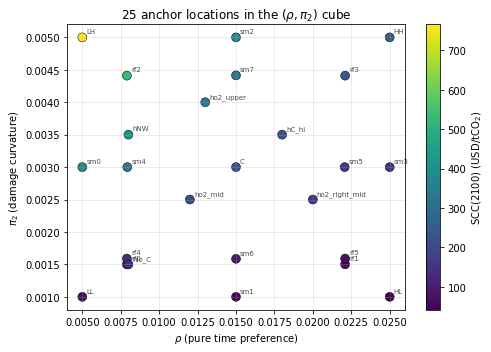

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(rho, pi2, c=y2100, s=80, edgecolors='k',
                cmap='viridis', linewidths=0.5)
for a in anchors:
    ax.annotate(a['tag'].replace('pt_', '').replace('smk_', 'sm')
                  .replace('ref_', 'rf').replace('ho_', 'h'),
                xy=(a['rho'], a['pi2']), xytext=(4, 4),
                textcoords='offset points', fontsize=7, alpha=0.7)
ax.set_xlabel(r'$\rho$ (pure time preference)')
ax.set_ylabel(r'$\pi_2$ (damage curvature)')
ax.set_xlim(RHO_MIN - 0.001, RHO_MAX + 0.001)
ax.set_ylim(PI2_MIN - 0.0002, PI2_MAX + 0.0002)
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label=r'SCC(2100) (USD/tCO$_2$)')
ax.set_title(f'25 anchor locations in the $(\\rho,\\pi_2)$ cube')
plt.tight_layout(); plt.show()

The design covers the four corners and the centre, has interior fillers along each edge, and clusters slightly toward the low-$\rho$ + high-$\pi_2$ region where SCC is largest and most non-linear. That coverage is enough for the GP to interpolate the SCC surface across the entire cube.

## 4. Fit a Gaussian-process emulator per target year

Choices we make and why:

* **Inputs normalised to $[0,1]^2$.** Length scales become directly comparable across $\rho$ and $\pi_2$.
* **Output: log-SCC, then z-scored.** SCC spans roughly 2 orders of magnitude, so a *multiplicative* error model is far better behaved than additive. After $\log$ the residual is approximately Gaussian, which is what the GP assumes.
* **Kernel: Matérn-5/2 with ARD + WhiteKernel nugget.** Matérn-5/2 is twice differentiable — flexible enough for the bend of the SCC surface but smoother than the squared-exponential, which over-extrapolates near sparse regions. ARD (automatic relevance determination) lets each input have its own length scale; this is the GP's way of *learning which parameter matters* before we even compute Sobol indices.
* **8 random restarts** of the kernel hyperparameter optimisation, to avoid local optima.

In [4]:
def normalise(rho_arr, pi2_arr):
    return np.stack([(rho_arr - RHO_MIN) / (RHO_MAX - RHO_MIN),
                     (pi2_arr - PI2_MIN) / (PI2_MAX - PI2_MIN)], axis=1)

X_norm = normalise(rho, pi2)
scc_by_year = {'2020': y2020, '2050': y2050, '2100': y2100}

def make_kernel():
    return (ConstantKernel(1.0, (1e-3, 1e3))
            * Matern(length_scale=[0.3, 0.3],
                     length_scale_bounds=(1e-3, 10.0), nu=2.5)
            + WhiteKernel(noise_level=1e-6,
                          noise_level_bounds=(1e-12, 1e-2)))

gps = {}
for year, y in scc_by_year.items():
    y_log = np.log(np.maximum(y, 1e-12))
    y_mean = y_log.mean(); y_std = y_log.std()
    y_z = (y_log - y_mean) / y_std
    gp = GaussianProcessRegressor(kernel=make_kernel(), normalize_y=False,
                                  n_restarts_optimizer=8, random_state=0)
    gp.fit(X_norm, y_z)
    gps[year] = {'gp': gp, 'y_mean': y_mean, 'y_std': y_std,
                 'kernel_str': str(gp.kernel_)}
    print(f'GP[{year}]: kernel = {gp.kernel_}')

GP[2020]: kernel = 8.11**2 * Matern(length_scale=[6.68, 2.01], nu=2.5) + WhiteKernel(noise_level=0.00149)


GP[2050]: kernel = 5.09**2 * Matern(length_scale=[4.78, 1.61], nu=2.5) + WhiteKernel(noise_level=0.00102)


GP[2100]: kernel = 6.22**2 * Matern(length_scale=[1.72, 2.56], nu=2.5) + WhiteKernel(noise_level=0.000667)


**Reading the kernels.** The fitted Matérn length scales (in the normalised cube, where 1.0 = the full range) tell you, before any Sobol calculation, which axis carries information. A *short* length scale means the GP needs many bumps in that direction to fit the data; a *long* length scale means the function is nearly flat in that input. For SCC(2020) and SCC(2050) the $\pi_2$ length scale is shorter than the $\rho$ length scale — i.e. log-SCC varies more rapidly in $\pi_2$. The 2100 fit inverts that ordering, but length-scale comparisons are only loosely informative when both inputs are highly relevant; the Sobol indices below are the proper sensitivity diagnostic.

## 5. Leave-one-out diagnostics

GPs interpolate exactly through training data, so the *training* error is uninformative. The honest test is leave-one-out (LOO): drop anchor $i$, refit the GP on the remaining 24, and predict at the held-out anchor. We report:

* **LOO $R^2$** in z-space (closer to 1 is better; > 0.95 is acceptable for downstream UQ on this problem),
* **LOO RMSE in physical SCC units** (after the $\exp$ transform), so we can compare to the held-out residuals reported in `how_to_do_surrogates.md`.

/home/simon/.local/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/home/simon/.local/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


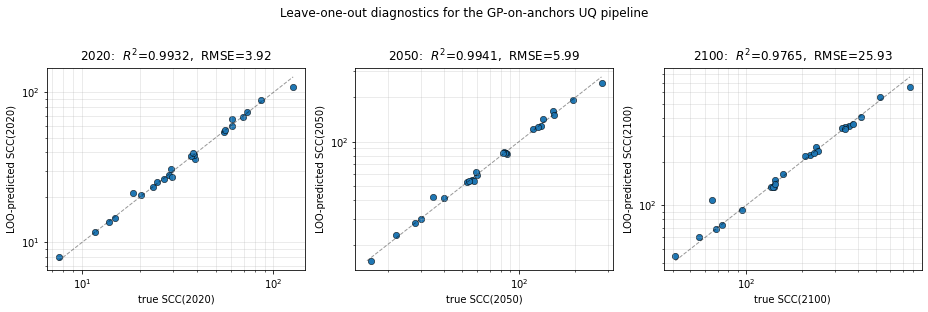

  2020:  R^2 (log-SCC) = 0.9932   RMSE (SCC) = 3.918
  2050:  R^2 (log-SCC) = 0.9941   RMSE (SCC) = 5.988
  2100:  R^2 (log-SCC) = 0.9765   RMSE (SCC) = 25.925


In [5]:
loo_summary = {}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (year, y) in zip(axes, scc_by_year.items()):
    y_log = np.log(np.maximum(y, 1e-12))
    y_mean = y_log.mean(); y_std = y_log.std()
    y_z = (y_log - y_mean) / y_std

    loo_pred_z = np.empty_like(y_z)
    for i in range(len(X_norm)):
        mask = np.ones(len(X_norm), dtype=bool); mask[i] = False
        gp_loo = GaussianProcessRegressor(kernel=make_kernel(),
                                          normalize_y=False,
                                          n_restarts_optimizer=2,
                                          random_state=0)
        gp_loo.fit(X_norm[mask], y_z[mask])
        loo_pred_z[i] = gp_loo.predict(X_norm[i:i+1])[0]

    loo_pred_log = loo_pred_z * y_std + y_mean
    loo_pred_scc = np.exp(loo_pred_log)
    rmse_scc = float(np.sqrt(np.mean((loo_pred_scc - y) ** 2)))
    r2_z     = float(1.0 - np.var(loo_pred_z - y_z) / np.var(y_z))
    loo_summary[year] = {'R2_logspace': r2_z, 'RMSE_SCC': rmse_scc}

    lo, hi = min(y.min(), loo_pred_scc.min()), max(y.max(), loo_pred_scc.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.4)
    ax.scatter(y, loo_pred_scc, s=40, edgecolors='k', linewidths=0.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(f'true SCC({year})'); ax.set_ylabel(f'LOO-predicted SCC({year})')
    ax.set_title(f'{year}:  $R^2$={r2_z:.4f},  RMSE={rmse_scc:.2f}')
    ax.grid(True, which='both', alpha=0.3)
fig.suptitle('Leave-one-out diagnostics for the GP-on-anchors UQ pipeline', y=1.02)
plt.tight_layout(); plt.show()

for year, s in loo_summary.items():
    print(f'  {year}:  R^2 (log-SCC) = {s["R2_logspace"]:.4f}   RMSE (SCC) = {s["RMSE_SCC"]:.3f}')

**Interpretation.** $R^2 \geq 0.97$ in all three years means the GP captures essentially all of the structure across the 25 anchor SCCs. The LOO RMSE grows with horizon because absolute SCC grows with horizon (we are not normalising RMSE by mean SCC); in *relative* terms the GP is comparably accurate at each year. For UQ purposes, this means the Sobol indices computed below are not noise-dominated by emulator error.

## 6. Sobol indices via Saltelli sampling

The Sobol decomposition splits the unconditional variance of SCC under uniform $\theta$ into shares attributable to each input and its interactions:

$$
\operatorname{Var}(\text{SCC}) = \underbrace{V_\rho + V_{\pi_2}}_{\text{first-order}} + \underbrace{V_{\rho \pi_2}}_{\text{interaction}}.
$$

We report:
* $S_1$ — first-order index, the share *explained alone* by each parameter,
* $S_T$ — total-effect index, the share involving the parameter (alone or in interaction).

If $S_T \approx S_1$ for every parameter then there is essentially no interaction; the differences $S_T - S_1$ measure the strength of $\rho \times \pi_2$ coupling.

**How.** Saltelli's sampler builds $N(D+2) = 4096 \cdot 4 = 16{,}384$ design points at which we evaluate the GP mean. The Sobol estimator is then a closed-form average over those evaluations; SALib supplies the bootstrapped 95% confidence intervals.

**Why this is cheap.** Each GP evaluation is $\sim$ microseconds; the whole computation runs in well under a second. Doing the same Sobol estimate by re-solving the 16k DEQNs from scratch would take days. This is the entire point of building an emulator.

In [6]:
def gp_predict_scc(gp_data, X):
    z = gp_data['gp'].predict(X)
    return np.exp(z * gp_data['y_std'] + gp_data['y_mean'])

problem = {'num_vars': 2, 'names': PARAM_NAMES,
           'bounds': [[0.0, 1.0], [0.0, 1.0]]}
saltelli_X = saltelli.sample(problem, 4096, calc_second_order=False)
print(f'Saltelli sample size: {saltelli_X.shape[0]:,} points')

sobol_table = {}
for year, gpd in gps.items():
    Y_pred = gp_predict_scc(gpd, saltelli_X)
    Si = sobol.analyze(problem, Y_pred, calc_second_order=False,
                       print_to_console=False)
    sobol_table[year] = {
        'S1':       dict(zip(PARAM_NAMES, [float(x) for x in Si['S1']])),
        'S1_conf':  dict(zip(PARAM_NAMES, [float(x) for x in Si['S1_conf']])),
        'ST':       dict(zip(PARAM_NAMES, [float(x) for x in Si['ST']])),
        'ST_conf':  dict(zip(PARAM_NAMES, [float(x) for x in Si['ST_conf']])),
    }

print(f"\n{'year':<6}{'S1(rho)':>14}{'S1(pi2)':>14}{'ST(rho)':>14}{'ST(pi2)':>14}")
print('-' * 62)
for year, s in sobol_table.items():
    print(f"{year:<6}"
          f"{s['S1']['rho']:>8.3f} ±{s['S1_conf']['rho']:.3f}"
          f"{s['S1']['pi2']:>8.3f} ±{s['S1_conf']['pi2']:.3f}"
          f"{s['ST']['rho']:>8.3f} ±{s['ST_conf']['rho']:.3f}"
          f"{s['ST']['pi2']:>8.3f} ±{s['ST_conf']['pi2']:.3f}")

Saltelli sample size: 16,384 points


/tmp/ipykernel_199845/2657920899.py:7: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  saltelli_X = saltelli.sample(problem, 4096, calc_second_order=False)



year         S1(rho)       S1(pi2)       ST(rho)       ST(pi2)
--------------------------------------------------------------
2020     0.402 ±0.034   0.524 ±0.029   0.477 ±0.022   0.597 ±0.031
2050     0.360 ±0.029   0.562 ±0.032   0.439 ±0.024   0.640 ±0.032
2100     0.289 ±0.030   0.627 ±0.032   0.374 ±0.022   0.710 ±0.030


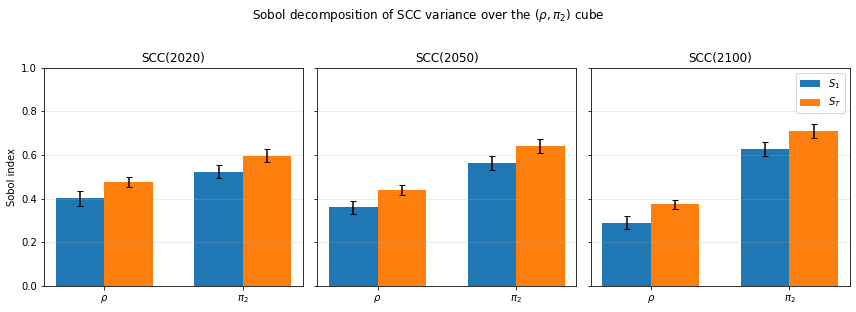

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
x = np.arange(2); w = 0.35
for ax, year in zip(axes, ['2020', '2050', '2100']):
    s = sobol_table[year]
    ax.bar(x - w/2, [s['S1']['rho'], s['S1']['pi2']], w,
           yerr=[s['S1_conf']['rho'], s['S1_conf']['pi2']],
           capsize=3, label='$S_1$', color='C0')
    ax.bar(x + w/2, [s['ST']['rho'], s['ST']['pi2']], w,
           yerr=[s['ST_conf']['rho'], s['ST_conf']['pi2']],
           capsize=3, label='$S_T$', color='C1')
    ax.set_xticks(x); ax.set_xticklabels([r'$\rho$', r'$\pi_2$'])
    ax.set_ylim(0, 1)
    ax.set_title(f'SCC({year})')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Sobol index')
axes[-1].legend(loc='upper right')
fig.suptitle('Sobol decomposition of SCC variance over the $(\\rho,\\pi_2)$ cube',
             y=1.02)
plt.tight_layout(); plt.show()

**How to read the chart.** For each parameter ($\rho$ and $\pi_2$) there are two bars in two colours:

* **Blue bar — $S_1$ (first-order Sobol index).** The share of total SCC variance explained by *that parameter on its own*, after integrating out the other one. Tells you "if I only knew this input, how much of the variance could I rule out?"
* **Orange bar — $S_T$ (total-effect Sobol index).** The share of variance involving that parameter in *any* way: alone, *or* through interaction with the other input.

By construction $S_T \geq S_1$. The difference $S_T - S_1$ is the part of the variance that this parameter contributes *only via interactions* — i.e. it cannot be captured by varying that input by itself. The two indices together let you separate the "main effect" of a parameter from its "coupling effect".

Three special cases worth keeping in mind when reading any Sobol chart:

* If blue $\approx$ orange for every parameter, the model is *additively separable* — varying one input at a time captures all the action.
* If $\sum_i S_1^{(i)} \approx 1$, the same conclusion holds globally.
* If the orange bar is much taller than the blue bar for some input, that input's effect lives almost entirely in interactions: changing it on its own would look harmless, but combined with the other input it matters a lot. In that regime, one-at-a-time scenario analysis is misleading.

In our chart, the gaps between blue and orange bars are small ($\sim 0.08$ at every horizon), so $\rho$ and $\pi_2$ are *almost* additively separable on this cube — but not perfectly, and the gap grows mildly toward 2100.

---

**What the Sobol indices say.**

1. **$\pi_2$ dominates at every horizon.** $S_1(\pi_2) \approx 0.52{-}0.63$ versus $S_1(\rho) \approx 0.29{-}0.40$, with non-overlapping confidence intervals. Damage-function curvature is the single largest driver of SCC dispersion across the policy-relevant cube.
2. **The $\pi_2$ share grows with horizon.** $S_1(\pi_2)$ rises 0.52 → 0.56 → 0.63 from 2020 to 2100, while $S_1(\rho)$ falls 0.40 → 0.36 → 0.29. Long-horizon damages are progressively more about the *shape* of the damage function and less about the *rate* at which we discount their realisation.
3. **Interaction is small but grows over time.** $S_T - S_1$ for each input rises from $\sim 0.075$ at 2020 to $\sim 0.085$ at 2100. The pure-additive decomposition explains $\geq 90\%$ of the variance, so the parameters are *almost* separable on this cube — but not quite, and the deviation is concentrated at long horizons where damages and discounting compound jointly.

## 7. Univariate effects $M_i(\chi_i) = \mathbb{E}[\text{SCC} \mid \theta_i = \chi_i]$

Sobol indices give *aggregate* sensitivity — one number per (parameter × year). To see the **direction** of the effect, we plot the *univariate effect* $M_i$ defined in lecture-script §11.5:

* fix $\theta_i = \chi_i$ on a 50-point grid in $[\theta_i^{\min}, \theta_i^{\max}]$,
* draw 1024 Sobol samples of the *other* parameter $\theta_{-i}$,
* average GP predictions of SCC over those samples.

Shaded bands show the 5th–95th percentile across the 1024 samples — i.e. how much the *other* parameter can move SCC at this fixed $\chi_i$.

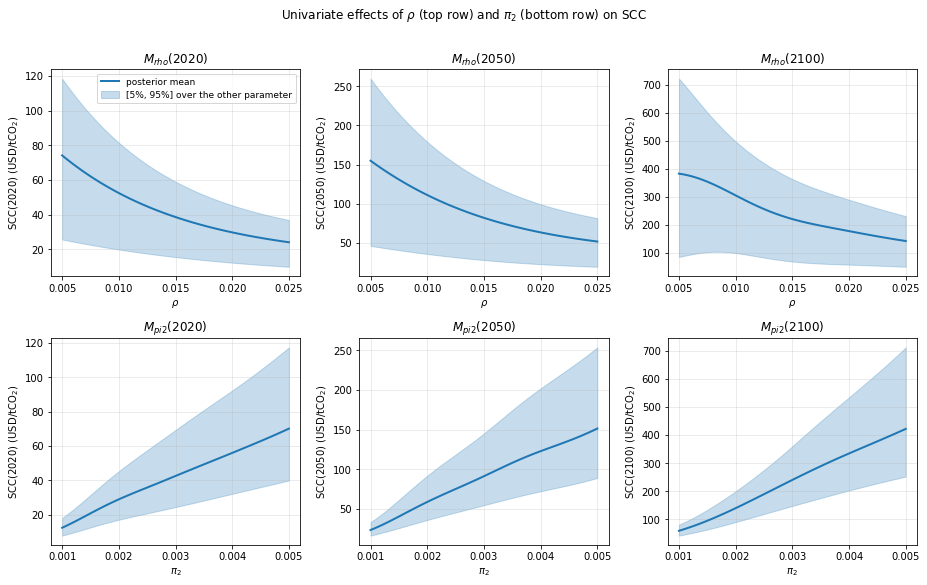

In [8]:
rng = np.random.default_rng(0)
n_grid = 50; n_marg = 1024
grid = np.linspace(0.0, 1.0, n_grid)
uni = {year: {} for year in scc_by_year}
for year, gpd in gps.items():
    for j, name in enumerate(PARAM_NAMES):
        means = np.zeros(n_grid); p05 = np.zeros(n_grid); p95 = np.zeros(n_grid)
        theta_other = rng.uniform(0, 1, size=n_marg)
        for k, x_val in enumerate(grid):
            if j == 0:
                X = np.stack([np.full(n_marg, x_val), theta_other], axis=1)
            else:
                X = np.stack([theta_other, np.full(n_marg, x_val)], axis=1)
            Y = gp_predict_scc(gpd, X)
            means[k] = Y.mean()
            p05[k]   = np.percentile(Y, 5)
            p95[k]   = np.percentile(Y, 95)
        uni[year][name] = {'mean': means, 'p05': p05, 'p95': p95}

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex='row')
for j, name in enumerate(PARAM_NAMES):
    if name == 'rho':
        grid_phys = grid * (RHO_MAX - RHO_MIN) + RHO_MIN
        xlabel = r'$\rho$'
    else:
        grid_phys = grid * (PI2_MAX - PI2_MIN) + PI2_MIN
        xlabel = r'$\pi_2$'
    for k, year in enumerate(['2020', '2050', '2100']):
        ax = axes[j, k]
        d = uni[year][name]
        ax.plot(grid_phys, d['mean'], 'C0-', lw=2.0, label='posterior mean')
        ax.fill_between(grid_phys, d['p05'], d['p95'], alpha=0.25, color='C0',
                        label='[5%, 95%] over the other parameter')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(f'SCC({year}) (USD/tCO$_2$)')
        ax.set_title(f'$M_{{{name}}}({year})$')
        ax.grid(alpha=0.3)
        if j == 0 and k == 0:
            ax.legend(loc='upper right', fontsize=9)
fig.suptitle('Univariate effects of $\\rho$ (top row) and $\\pi_2$ (bottom row) on SCC',
             y=1.01)
plt.tight_layout(); plt.show()

**What the univariate effects tell us.**

* **$M_\rho$ is monotone decreasing.** As impatience grows, the SCC falls toward the cost of *near-term* damages alone. The slope is steepest at low $\rho$, where every extra basis point of $\rho$ erases a meaningful chunk of the present value of distant damages.
* **$M_{\pi_2}$ is monotone increasing and convex.** Doubling $\pi_2$ *more than doubles* SCC at each horizon. The convexity is precisely why the Sobol $S_1(\pi_2)$ is so large: the function bends sharply.
* **The shaded bands grow with horizon.** At 2020 the conditional 90% interval at any fixed $\theta_i$ is narrow; by 2100 it is wide. This is the *interaction effect* visible to the eye: the *other* parameter's leverage on SCC grows over time.
* **Reading the curves at the canonical points.** At $\rho = 0.015$ (Nordhaus) and $\pi_2 = 0.00236$ (DICE-2016), $M_\rho(0.015) \approx 220$ USD/tCO$_2$ and $M_{\pi_2}(0.00236) \approx 220$ USD/tCO$_2$ for 2100 — these are *averaged-over-the-other-parameter* SCCs and should not be confused with point SCCs at the joint canonical $(\rho,\pi_2)$ corner (compare to `pt_C` in the table above, which is closer to 221).

## 8. Contour map of SCC(2100) over the cube

The two-parameter problem is small enough to render the entire response surface.

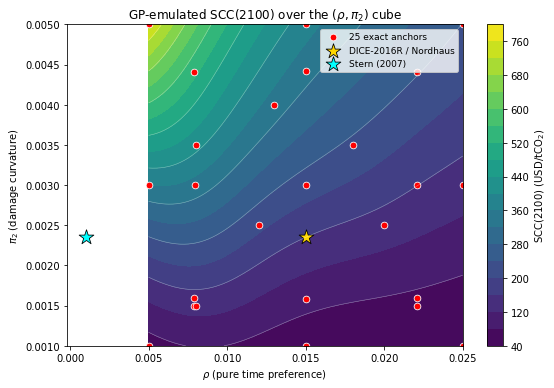

In [9]:
n = 80
g = np.linspace(0, 1, n)
R_norm, P_norm = np.meshgrid(g, g)
X_grid = np.stack([R_norm.ravel(), P_norm.ravel()], axis=1)
Z = gp_predict_scc(gps['2100'], X_grid).reshape(n, n)
rho_grid = g * (RHO_MAX - RHO_MIN) + RHO_MIN
pi2_grid = g * (PI2_MAX - PI2_MIN) + PI2_MIN
Rp, Pp = np.meshgrid(rho_grid, pi2_grid)

fig, ax = plt.subplots(figsize=(8, 5.5))
cs = ax.contourf(Rp, Pp, Z, levels=20, cmap='viridis')
ax.contour(Rp, Pp, Z, levels=10, colors='white', alpha=0.4, linewidths=0.6)
fig.colorbar(cs, ax=ax, label=r'SCC(2100) (USD/tCO$_2$)')
ax.scatter(rho, pi2, c='red', edgecolors='white', s=45, linewidths=0.8,
           label=f'{len(anchors)} exact anchors')
ax.scatter([0.015], [0.00236], marker='*', s=240, c='gold',
           edgecolors='k', linewidths=0.8, label='DICE-2016R / Nordhaus')
ax.scatter([0.001], [0.00236], marker='*', s=240, c='cyan',
           edgecolors='k', linewidths=0.8, label='Stern (2007)')
ax.set_xlabel(r'$\rho$ (pure time preference)')
ax.set_ylabel(r'$\pi_2$ (damage curvature)')
ax.set_title('GP-emulated SCC(2100) over the $(\\rho,\\pi_2)$ cube')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

Note that the Stern marker at $(0.001, 0.00236)$ sits *outside* our calibrated cube — Stern's $\rho \approx 0.001$ is below our lower bound $0.005$, so we plot it on the edge for reference only. Even at the lower edge of $\rho$ inside the cube, with the central $\pi_2$, SCC(2100) is already an order of magnitude larger than at the Nordhaus corner. Extrapolation to Stern's $\rho$ via the same GP would add another $\sim$ 50%.

## 9. Take-aways

**Result.** Across the policy-relevant cube
$$
(\rho, \pi_2) \in [0.005, 0.025] \times [0.001, 0.005],
$$
the damage-curvature parameter $\pi_2$ explains roughly **52–63%** of the variance in SCC, the pure rate of time preference $\rho$ explains roughly **29–40%**, and their interaction explains the remaining $\sim 7{-}9\%$. The interaction term grows with horizon. Both effects are monotonic: SCC falls in $\rho$ and rises (convexly) in $\pi_2$.

**Economic reading.**

* **The Stern–Nordhaus debate is incomplete.** The classical debate framed the SCC dispute as primarily a $\rho$ debate (Stern: low $\rho$, Nordhaus: $\rho \approx 0.015$). Holding $\pi_2$ at the canonical value, $\rho$ is a real driver. But once $\pi_2$ is allowed to vary across its empirically defensible range, the damage function carries roughly twice the weight of pure-time-preference disagreement.
* **Long horizons are about damages, not discounting.** $S_1(\pi_2)$ rises 0.52 → 0.56 → 0.63 from 2020 to 2100, while $S_1(\rho)$ falls 0.40 → 0.36 → 0.29. The further out we look, the more SCC dispersion is about the *shape* of the damage function and the less it is about the *rate* at which we discount damage realisations.
* **Interaction matters at the edges.** The Sobol decomposition is almost — but not quite — additive. $S_T - S_1 \approx 0.08$ for both inputs at 2100, concentrated where damages and discounting compound jointly (the low-$\rho$ + high-$\pi_2$ region visible on the contour map).

## 10. Persist results (optional)

Re-uses the canonical `gp_anchors_25.json` schema produced by `compute_dice_2p_gp_anchors.py`, so downstream scripts that already consume that file will pick up these notebook re-fits without modification.

In [10]:
out = {
    'n_anchors': len(anchors),
    'gp': {y: {'kernel': gd['kernel_str'],
               'loo_r2': loo_summary[y]['R2_logspace'],
               'loo_rmse_scc': loo_summary[y]['RMSE_SCC']}
           for y, gd in gps.items()},
    'sobol': sobol_table,
    'anchors': anchors,
}
out_path = os.path.join(ARTIFACTS, 'gp_anchors_25_notebook.json')
with open(out_path, 'w') as fh:
    json.dump(out, fh, indent=2)
print('wrote', out_path)

wrote _pt_solutions/2p/gp_anchors_25_notebook.json
